# EXPLOLATORY ANALYZES

## Reading the data

In [75]:
import pandas as pd

df = pd.read_csv('transactional-sample.csv')
df.head(5)

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False


## 1.BASIC DATA QUALITY CHECKS

### MISSING VALUES & DUPLICATES

#### Missing values

In [76]:
# Checking for MISSING VALUES
df.isnull().sum()

transaction_id          0
merchant_id             0
user_id                 0
card_number             0
transaction_date        0
transaction_amount      0
device_id             830
has_cbk                 0
dtype: int64

#### Duplicates

In [77]:
# Checking for Full_rows duplicates
df.duplicated().sum()

np.int64(0)

In [78]:
# Checking for duplicate transaction_id
df['transaction_id'].duplicated().sum()

np.int64(0)

In [79]:
# Checking for Near-Duplicates
df_nd = df.copy()
df_nd['transaction_date'] = pd.to_datetime(df_nd['transaction_date'])
df_nd = df.sort_values('transaction_date')

threshold = pd.Timedelta(minutes=2)

df_nd['time_diff'] = df_nd.groupby(['user_id', 'card_number', 'merchant_id', 'transaction_amount'])['transaction_date'].diff()
df_nd['is_near_duplicate'] = df_nd['time_diff'].notna() & (df_nd['time_diff'] <= threshold)

near_duplicates = df_nd[df_nd['is_near_duplicate']]
near_duplicates

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk,time_diff,is_near_duplicate


### DATA TYPES

In [80]:
# Checking types
df.dtypes

transaction_id          int64
merchant_id             int64
user_id                 int64
card_number               str
transaction_date          str
transaction_amount    float64
device_id             float64
has_cbk                  bool
dtype: object

In [81]:
# Confirming the type of transaction_date and making sure the range makes sense
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
min_date = df['transaction_date'].min()

max_date = df['transaction_date'].max()
print(f"Data range:{min_date} to {max_date}")

Data range:2019-11-01 01:27:15.811098 to 2019-12-01 23:16:32.812632


In [82]:
# Checking for format consistency in card_number across all rows
expected_pattern = r'^\d{6}\*{6}\d{4}$'
df_valid_card_number = df.copy() 
df_valid_card_number['is_format_valid'] = df['card_number'].dropna().astype(str).str.match(expected_pattern, na=False)

print(df_valid_card_number['is_format_valid'].value_counts())
print(f"Invalid rows: {df_valid_card_number[~df_valid_card_number['is_format_valid']].shape[0]}")

is_format_valid
True     3160
False      39
Name: count, dtype: int64
Invalid rows: 39


### Range / sanity checks on transaction_amount

In [83]:
# Data from the column
df['transaction_amount'].describe()

count    3199.000000
mean      767.812904
std       889.095904
min         1.220000
25%       205.235000
50%       415.940000
75%       981.680000
max      4097.210000
Name: transaction_amount, dtype: float64

In [84]:
# Checking for negative amounts
df[df['transaction_amount'] < 0]

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk


In [85]:
# Checking for zero amounts
df[df['transaction_amount'] == 0]

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk


In [86]:
# Checking for extreme outliers (using IQR)

# Understanding the tail
percentiles = [0.90, 0.95, 0.99, 0.999, 0.9999]
for p in percentiles:
    value = df['transaction_amount'].quantile(p)
    print(f"Percentile {p*100:.2f}%: {value:.2f}")

# Checking the absolute maximum
print(f"Maximum value: {df['transaction_amount'].max():.2f}")

# Looking at the top 10 largest transactions
top_10 = df.nlargest(10, 'transaction_amount')[['transaction_id', 'transaction_amount']]
print(top_10)

Percentile 90.00%: 2074.93
Percentile 95.00%: 2775.27
Percentile 99.00%: 4028.55
Percentile 99.90%: 4089.85
Percentile 99.99%: 4096.77
Maximum value: 4097.21
      transaction_id  transaction_amount
2516        21322914             4097.21
1713        21322111             4095.82
2550        21322948             4091.83
2651        21323049             4089.88
1277        21321675             4089.73
920         21321318             4080.03
684         21321082             4078.80
1707        21322105             4077.47
2776        21323174             4077.07
1293        21321691             4076.40


In [87]:
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1

standard_upper_bound = Q3 + 1.5 * IQR
extreme_upper_bound = Q3 + 3.0 * IQR  # More aggressive for fraud

print(f"Standard IQR upper bound: {standard_upper_bound:.2f}")
print(f"Extreme IQR upper bound: {extreme_upper_bound:.2f}")

Standard IQR upper bound: 2146.35
Extreme IQR upper bound: 3311.02


In [88]:
# Option A: Statistical (Top 1%)
p99 = df['transaction_amount'].quantile(0.99)
df_IQR = df.copy()
df_IQR['is_amount_extreme'] = df_IQR['transaction_amount'] > p99

# Option B: Business Rule (e.g., anything over $10,000)
# df['is_amount_extreme'] = df['transaction_amount'] > 10000

# Count how many you flagged
print(f"Flagged {df_IQR['is_amount_extreme'].sum()} transactions as extreme outliers.")

Flagged 31 transactions as extreme outliers.


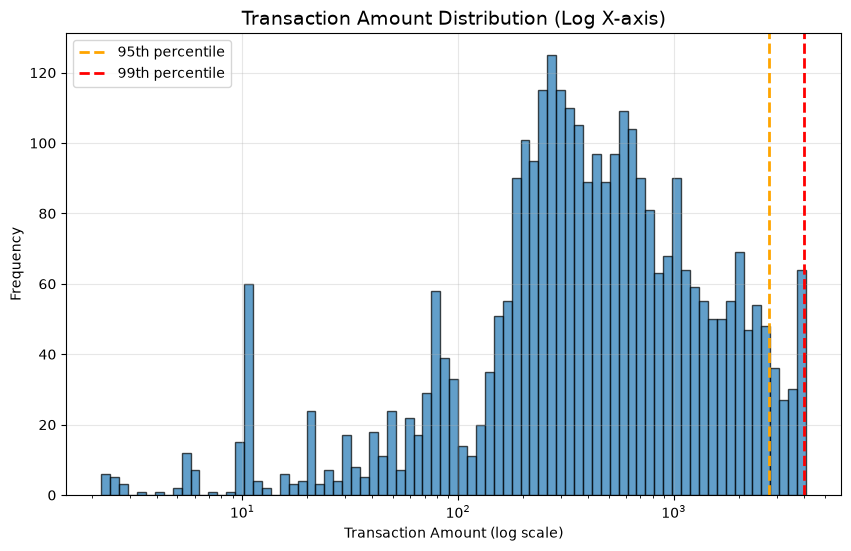

In [ ]:
# Ploting a histogram to get a visual sense of the shape

import matplotlib.pyplot as plt
import numpy as np

log_bins = np.logspace(
    np.log10(df['transaction_amount'].min() + 1),
    np.log10(df['transaction_amount'].max() + 1),
    num=80
)

plt.figure(figsize=(10, 6))
plt.hist(df['transaction_amount'], bins=log_bins, edgecolor='black', alpha=0.7)

# Add percentile reference lines
plt.axvline(df['transaction_amount'].quantile(0.95), color='orange', linestyle='--', linewidth=2, label='95th percentile')
plt.axvline(df['transaction_amount'].quantile(0.99), color='red', linestyle='--', linewidth=2, label='99th percentile')

plt.xscale('log')

plt.title('Transaction Amount Distribution (Log X-axis)', fontsize=14)
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Overall has_cbk rate (class imbalance)

In [102]:
df['has_cbk'].value_counts(normalize=True)

has_cbk
False    0.877774
True     0.122226
Name: proportion, dtype: float64

## 2.UNIVARIATE ANALYSIS OF HAS_CBK

### By merchant_id

In [150]:
df_merchant = df.copy()
df_merchant = df_merchant.groupby('merchant_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_merchant[df_merchant['number_of_transactions']>10].sort_values('rate')

,number_of_transactions,rate
merchant_id,,
4129,14,0.000000
26981,16,0.000000
26765,18,0.000000
17348,16,0.000000
49205,73,0.000000
42178,15,0.000000
36929,13,0.000000
29931,12,0.000000
93881,11,0.000000


### By user_id

In [149]:
df_user_id = df.copy()
df_user_id = df_user_id.groupby('user_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_user_id[df_user_id['number_of_transactions']>10].sort_values('rate')

,number_of_transactions,rate
user_id,,
11750,31,0.806452
91637,22,0.863636
79054,17,0.882353
78262,13,0.923077
96025,14,0.928571


### By device_id

In [141]:
df_device_id = df.copy()
df_device_id = df_device_id.groupby('device_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_device_id = df_device_id[df_device_id['number_of_transactions']>10].sort_values('rate').reset_index()
df_numb_users = df.groupby('device_id')['user_id'].agg(number_of_users = 'nunique').reset_index()
print(f"Devices with more than one user:\n{df_numb_users[df_numb_users['number_of_users']>1]} \nRate of devices with more than 10 transactions:\n{df_device_id}")

Devices with more than one user:
Empty DataFrame
Columns: [device_id, number_of_users]
Index: [] 
Rate of devices with more than 10 transactions:
   device_id  number_of_transactions      rate
0   342890.0                      19  0.789474
1   563499.0                      22  0.863636
2   101848.0                      17  0.882353
3   547440.0                      13  0.923077
4   438940.0                      14  0.928571


### By card_number

In [147]:
df_card_number = df.copy()
df_card_number = df_card_number.groupby('device_id')['has_cbk'].agg(number_of_transactions='count', rate='mean')
df_card_number = df_card_number[df_card_number['number_of_transactions']>10].sort_values('rate')
df_numb_devices = df.groupby('card_number')['device_id'].agg(number_of_devices = 'nunique').reset_index()
df_numb_users_card = df.groupby('card_number')['user_id'].agg(number_of_users = 'nunique').reset_index()
print(f"Cards with more than 2 devices:\n{df_numb_devices[df_numb_devices['number_of_devices']>2]}\nCards with more than 2 users:\n{df_numb_users_card[df_numb_users_card['number_of_users']>2]} \nRate of cards with more than 10 transactions:\n{df_card_number}")

Cards with more than 2 devices:
          card_number  number_of_devices
876  496045******1160                  4
Cards with more than 2 users:
           card_number  number_of_users
876   496045******1160                4
2493  550209******6420                3 
Rate of cards with more than 10 transactions:
           number_of_transactions      rate
device_id                                  
342890.0                       19  0.789474
563499.0                       22  0.863636
101848.0                       17  0.882353
547440.0                       13  0.923077
438940.0                       14  0.928571


## 3. Transaction amount patterns